# Week 2 — Notebook 4: Isolation Forest — Anomaly Detection
**Project:** ML-Based IDS for IoT Networks | **Student:** Aryan Thapa | AM.SC.P2CSN25005

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('Libraries loaded')

Libraries loaded


## 1. Load Data & RF Model

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train_binary.npy')
y_test  = np.load('../data/processed/y_test_binary.npy')
rf_model = joblib.load('../models/random_forest_binary.pkl')

# Normal traffic only — IF trains on this
X_train_normal = X_train[y_train == 0]
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Normal training samples for IF: {len(X_train_normal):,}')

X_train: (37370, 10) | X_test: (10807, 10)
Normal training samples for IF: 370


## 2. Train Isolation Forest on Normal Traffic Only

In [3]:
iso_forest = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=0.01,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)
print('Training Isolation Forest on normal traffic only...')
iso_forest.fit(X_train_normal)
print('Done.')

Training Isolation Forest on normal traffic only...
Done.


## 3. Anomaly Scores on Test Set

In [4]:
if_scores_raw = iso_forest.decision_function(X_test)
if_labels     = iso_forest.predict(X_test)           # -1=anomaly, 1=normal
if_binary     = np.where(if_labels == -1, 1, 0)      # convert to 0/1

# Normalise to [0,1]: higher = more anomalous
s_min, s_max = if_scores_raw.min(), if_scores_raw.max()
if_scores_norm = 1 - (if_scores_raw - s_min) / (s_max - s_min)

print(f'Anomalies detected: {(if_binary==1).sum():,} / {len(if_binary):,}')
print(f'Raw score range: [{s_min:.4f}, {s_max:.4f}]')

Anomalies detected: 8,072 / 10,807
Raw score range: [-0.1142, 0.2909]


## 4. Score Distribution & ROC Comparison

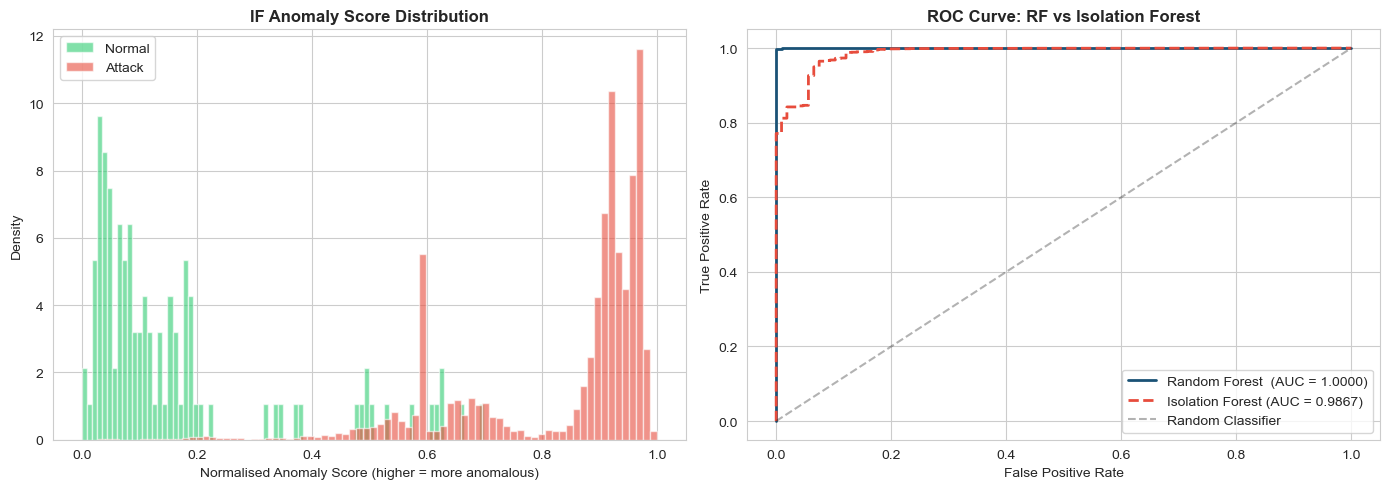

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution by true label
axes[0].hist(if_scores_norm[y_test==0], bins=80, alpha=0.6,
             color='#2ecc71', label='Normal', density=True)
axes[0].hist(if_scores_norm[y_test==1], bins=80, alpha=0.6,
             color='#e74c3c', label='Attack', density=True)
axes[0].set_xlabel('Normalised Anomaly Score (higher = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].set_title('IF Anomaly Score Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# ROC Curve: RF vs IF
rf_probs = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_if, tpr_if, _ = roc_curve(y_test, if_scores_norm)
auc_rf = roc_auc_score(y_test, rf_probs)
auc_if = roc_auc_score(y_test, if_scores_norm)

axes[1].plot(fpr_rf, tpr_rf, color='#1A5276', lw=2,
             label=f'Random Forest  (AUC = {auc_rf:.4f})')
axes[1].plot(fpr_if, tpr_if, color='#e74c3c', lw=2, linestyle='--',
             label=f'Isolation Forest (AUC = {auc_if:.4f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.3, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: RF vs Isolation Forest', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/if_vs_rf_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluate Isolation Forest

=== ISOLATION FOREST RESULTS ===
              precision    recall  f1-score   support

      Normal       0.04      1.00      0.08       107
      Attack       1.00      0.75      0.86     10700

    accuracy                           0.76     10807
   macro avg       0.52      0.88      0.47     10807
weighted avg       0.99      0.76      0.85     10807



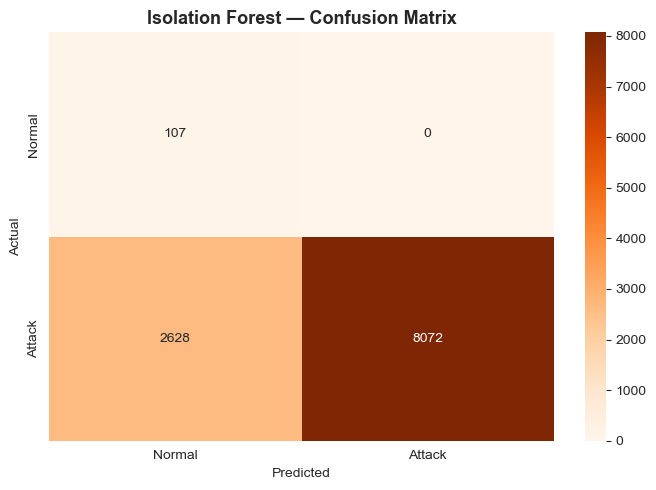

In [6]:
print('=== ISOLATION FOREST RESULTS ===')
print(classification_report(y_test, if_binary, target_names=['Normal','Attack']))

cm_if = confusion_matrix(y_test, if_binary)
plt.figure(figsize=(7,5))
sns.heatmap(cm_if, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
plt.title('Isolation Forest — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../reports/if_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model Comparison Table

In [7]:
rf_preds = rf_model.predict(X_test)

results = pd.DataFrame({
    'Model':     ['Random Forest', 'Isolation Forest'],
    'Type':      ['Supervised',    'Unsupervised'],
    'Accuracy':  [accuracy_score(y_test, rf_preds),  accuracy_score(y_test, if_binary)],
    'Precision': [precision_score(y_test, rf_preds), precision_score(y_test, if_binary)],
    'Recall':    [recall_score(y_test, rf_preds),    recall_score(y_test, if_binary)],
    'F1-Score':  [f1_score(y_test, rf_preds),        f1_score(y_test, if_binary)],
    'AUC-ROC':   [auc_rf, auc_if]
}).set_index('Model').round(4)

print('=== MODEL COMPARISON ===')
print(results.to_string())
results.to_csv('../reports/week2_model_comparison.csv')
print('\nSaved: ../reports/week2_model_comparison.csv')

=== MODEL COMPARISON ===
                          Type  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                                         
Random Forest       Supervised    0.9986     0.9999  0.9987    0.9993   1.0000
Isolation Forest  Unsupervised    0.7568     1.0000  0.7544    0.8600   0.9867

Saved: ../reports/week2_model_comparison.csv


## 7. Hybrid RF + IF Pipeline

In [8]:
RF_CONF_THRESHOLD = 0.7   # RF confidence below this → escalate to IF
IF_SCORE_THRESHOLD = 0.6  # IF anomaly score above this → flag attack

rf_probs_all = rf_model.predict_proba(X_test)
rf_preds_all = rf_model.predict(X_test)

hybrid = []
for i in range(len(X_test)):
    rf_conf = rf_probs_all[i][rf_preds_all[i]]
    if rf_conf >= RF_CONF_THRESHOLD:
        hybrid.append(rf_preds_all[i])           # Trust RF
    else:
        if if_scores_norm[i] >= IF_SCORE_THRESHOLD:
            hybrid.append(1)                      # IF catches it
        else:
            hybrid.append(rf_preds_all[i])        # Keep RF anyway

hybrid = np.array(hybrid)

print('=== HYBRID RF + IF RESULTS ===')
print(classification_report(y_test, hybrid, target_names=['Normal','Attack']))
print(f'Accuracy: {accuracy_score(y_test, hybrid):.4f}')
print(f'F1-Score: {f1_score(y_test, hybrid):.4f}')

=== HYBRID RF + IF RESULTS ===
              precision    recall  f1-score   support

      Normal       0.89      0.99      0.94       107
      Attack       1.00      1.00      1.00     10700

    accuracy                           1.00     10807
   macro avg       0.95      0.99      0.97     10807
weighted avg       1.00      1.00      1.00     10807

Accuracy: 0.9987
F1-Score: 0.9993


## 8. Save Models & Thresholds

In [9]:
joblib.dump(iso_forest, '../models/isolation_forest.pkl')
print('Saved: ../models/isolation_forest.pkl')

thresholds = {
    'rf_confidence_threshold': RF_CONF_THRESHOLD,
    'if_anomaly_threshold': IF_SCORE_THRESHOLD,
    'if_score_min': float(s_min),
    'if_score_max': float(s_max)
}
with open('../models/hybrid_thresholds.json', 'w') as f:
    json.dump(thresholds, f, indent=2)
print('Saved: ../models/hybrid_thresholds.json')

print()
print('=== WEEK 2 COMPLETE ===')
print('All 4 models/artifacts saved:')
print('  random_forest_binary.pkl')
print('  random_forest_multiclass.pkl')
print('  isolation_forest.pkl')
print('  label_encoder.pkl')
print('  scaler.pkl')
print('  hybrid_thresholds.json')
print()
print('Next: Week 3 -> Feature tuning, hyperparameter search, Flask API')

Saved: ../models/isolation_forest.pkl
Saved: ../models/hybrid_thresholds.json

=== WEEK 2 COMPLETE ===
All 4 models/artifacts saved:
  random_forest_binary.pkl
  random_forest_multiclass.pkl
  isolation_forest.pkl
  label_encoder.pkl
  scaler.pkl
  hybrid_thresholds.json

Next: Week 3 -> Feature tuning, hyperparameter search, Flask API
